# Planning Through ODE Transitions With Diffrax and JaxPlan

This notebook discusses how to leverage differentiable ODE solvers in RDDL domain description files to allow for more complex state transitions.

It then defines a Multistage Extraction Column (MEC) domain requiring ODEs for the cpfs and solves it by optimizing a straight-line plan (SLP). The system of ODEs is solved using a differentiable ODE solver from Diffrax (https://docs.kidger.site/diffrax/).

The MEC system is a counter-current liquid-gas extraction process with 5 stages. Its state dynamics describe the mass transfer of a solute between the phases through each stage, and is represented with a system of 10 ODEs [1, 2]:

\begin{align*}
\frac{dX_n}{dt}
&= \frac{1}{V_l}\left(L(X_{n-1}-X_n)-Q_n\right), \\
\frac{dY_n}{dt}
&= \frac{1}{V_g}\left(G(Y_{n+1}-Y_n)+Q_n\right)
\end{align*}
Where,
\begin{align*}
X_{n,\mathrm{eq}}
&= \frac{Y_n^e}{m}, \\
Q_n
&= K_{la}\left(X_n-X_{n,\mathrm{eq}}\right)V_l,
\end{align*}

A typical control objective is to maintain desired output concentrations at a certain level (the "setpoint" of a state).

*Nonfluents*: $V_l$ is the liquid volume in each stage, $V_g$ is the gas volume in each stage, $m$ is the equilibrium constant, $K_{la}$ is the mass transfer capacity constant, $e$ is the equilibrium exponent, $X_0$ is the feed concentration of solute in the liquid phase, and $Y_6$ is the feed concentration of solute in the gas phase.

*Fluents*: $X_n$ is the concentration of solute in the liquid phase at stage $n$, and $Y_n$ is the concentration of solute in the gas phase at stage $n$, where $n=1,\ldots,5$.

*Actions*: $L$ represents the liquid flow rate, and $G$ represents the gas flow rate.

*Reward*: The reward will be the distance from the states to their respective setpoints, common in continuous control, with a penalty for going past state boundaries.

In [1]:
%pip install --quiet --upgrade pip
%pip install --quiet pyRDDLGym rddlrepository pyRDDLGym-jax
%pip install --quiet -U diffrax

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 4.7 MB/s eta 0:00:00


Import required packages:

In [2]:
import jax
import jax.numpy as jnp
import diffrax
import numpy as np
import matplotlib.pyplot as plt

import pyRDDLGym
from rddlrepository.core.manager import RDDLRepoManager
from pyRDDLGym_jax.core.planner import (
    JaxStraightLinePlan,
    JaxBackpropPlanner,
    JaxOfflineController
)

/usr/local/lib/python3.13/dist-packages/pyRDDLGym/core/debug/exception.py:28: UserWarning: Failed to load the dashboard visualization tool: ensure all prerequisite packages are installed.
  warnings.warn(message)
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/pyRDDLGym_jax/core/planner.py", line 80, in <module>
    from pyRDDLGym_jax.core.visualization import JaxPlannerDashboard
  File "/usr/local/lib/python3.13/dist-packages/pyRDDLGym_jax/core/visualization.py", line 33, in <module>
    import dash
ModuleNotFoundError: No module named 'dash'


Here are helper functions for evaluating plans and plotting states:

In [ ]:
def rollout_episode(env, planner):
    """
    Roll out one episode using the planner.
    """
    planner.reset()
    state, _ = env.reset()
    states = [state.copy()]
    rewards = 0

    for _ in range(env.horizon):
        action = planner.sample_action(state)
        next_state, reward, terminated, truncated, _ = env.step(action)

        rewards += reward
        states.append(next_state.copy())
        state = next_state

        if terminated or truncated:
            break

    return states, rewards

def rollout_actions(env, actions):
    """Roll out using list of actions instead of a planner."""
    state, _ = env.reset()
    states = [state.copy()]
    rewards = 0

    for step in range(env.horizon):
        action = {
            "action": np.array(actions[step])
        }
        next_state, reward, terminated, truncated, _ = env.step(action)

        rewards += reward
        states.append(next_state.copy())

        state = next_state

        if terminated or truncated:
            break

    return states, rewards

def plot_rollout(traj1, traj2=None):
    states1 = np.array([x["state"] for x in traj1])
    sps = np.array([x["SP"] for x in traj1])
    steps1 = np.arange(len(states1))

    n_states = states1.shape[1]
    state_names = [f"X{i}" for i in range(1, 6)] + [f"Y{i}" for i in range(1, 6)]

    if traj2 is not None:
        states2 = np.array([x["state"] for x in traj2])
        steps2 = np.arange(len(states2))

    fig, axes = plt.subplots(
        n_states, 1,
        figsize=(8, 3 * n_states),
        sharex=True,
        layout="constrained"
    )

    if n_states == 1:
        axes = [axes]

    for i, ax in enumerate(axes):
        ax.plot(steps1, states1[:, i], label="TSit5")

        if traj2 is not None:
            ax.plot(steps2, states2[:, i], label="Euler")

        ax.plot(steps1, sps[:, i], "--", label="Setpoint")

        ax.set_title(state_names[i])
        ax.set_ylabel("Concentration (kg/m³)")
        ax.legend()
        ax.grid(True)

    axes[-1].set_xlabel("Step")
    fig.suptitle("Multistage Extraction Column Rollout", fontsize=16)

    plt.show()

# Defining ODEs in Diffrax

Let's define the next state CPF as a system of ODEs solved using  Diffrax. Tsit5 is the Tsitouras' 5/4 method (5th order explicit Runge-Kutta method).

In [4]:
@jax.jit
def mec_next_state(state, action, parameters):
    """
    MEC simulation using diffrax adaptive Runge-Kutta integrator.
    """
    Vl, Vg, m, Kla, e, X0, Y6 = parameters

    L, G = action

    # Define the ODE function
    def dynamics(t, y, args):
        X1, X2, X3, X4, X5, Y1, Y2, Y3, Y4, Y5 = y

        X = jnp.array([X1, X2, X3, X4, X5])
        X_prev = jnp.array([X0, X1, X2, X3, X4])
        Y = jnp.array([Y1, Y2, Y3, Y4, Y5])
        Y_next = jnp.array([Y2, Y3, Y4, Y5, Y6])

        Xn_eq = Y ** e / m
        Qn = Kla * (X - Xn_eq) * Vl

        dX_dt = 1 / Vl * (L * (X_prev - X) - Qn)
        dY_dt = 1 / Vg * (G * (Y_next - Y) + Qn)

        return jnp.concatenate([dX_dt, dY_dt])

    solver = diffrax.Tsit5()

    # Initial condition
    y0 = jnp.array(state)

    term = diffrax.ODETerm(dynamics)

    sol = diffrax.diffeqsolve(
        term,
        solver,
        t0=0,
        t1=1.0,  # Each step is 1 minute
        dt0=0.1,  # Initial step size guess
        y0=y0,
        args=None,
        stepsize_controller=diffrax.PIDController(rtol=1e-5, atol=1e-5)
    )

    return sol.ys[-1]

# RDDL File With External Diffrax Call

Next, we create a MEC RDDL domain where the next states transition following ODEs. For simplicity, we will only track the setpoint for X5.

In [5]:
domain_text = """
domain mec {
    requirements { reward-deterministic, cpf-deterministic, continuous };

    types {
        state-components : {
            @X1,    // Concentration of solute in liquid phase at stage 1 (kg/m^3)
            @X2,    // Concentration of solute in liquid phase at stage 2 (kg/m^3)
            @X3,    // Concentration of solute in liquid phase at stage 3 (kg/m^3)
            @X4,    // Concentration of solute in liquid phase at stage 4 (kg/m^3)
            @X5,    // Concentration of solute in liquid phase at stage 5 (kg/m^3)
            @Y1,    // Concentration of solute in gas phase at stage 1 (kg/m^3)
            @Y2,    // Concentration of solute in gas phase at stage 2 (kg/m^3)
            @Y3,    // Concentration of solute in gas phase at stage 3 (kg/m^3)
            @Y4,    // Concentration of solute in gas phase at stage 4 (kg/m^3)
            @Y5     // Concentration of solute in gas phase at stage 5 (kg/m^3)
        };

        action-components : {
            @L,     // Liquid flow rate (m^3/Hr)
            @G      // Gas flow rate (m^3/Hr)
        };

        parameters : {
            @Vl,    // Liquid volume in each stage (m^3)
            @Vg,    // Gas volume in each stage (m^3)
            @m,     // Equilibrium constant
            @Kla,   // Mass transfer capacity constant (1/Hr)
            @e,     // Equilibrium exponent
            @X0,    // Feed concentration of liquid (kg/m^3) (disturbance)
            @Y6     // Feed concentration of gas (kg/m^3) (disturbance)
        };
    };

    pvariables {
        // constants
        STATE-MAX(state-components) : { non-fluent, real, default = 1.0 }; // maximum concentration in each stage (kg/m^3)
        STATE-MIN(state-components) : { non-fluent, real, default = 0.0 }; // minimum concentration in each stage (kg/m^3)
        SP-MAX(state-components) : { non-fluent, real, default = 0.4000001 }; // maximum allowable set-point for each state (kg/m^3)
        SP-MIN(state-components) : { non-fluent, real, default = 0.3 }; // minimum allowable set-point for each state (kg/m^3)
        ACT-MAX(action-components) : { non-fluent, real, default = 500.0 }; // maximum allowable action for each action (m^3/Hr)
        ACT-MIN(action-components) : { non-fluent, real, default = 5.0 }; // minimum allowable action for each action (m^3/Hr)

        TRACK-SP(state-components) : { non-fluent, bool, default = false }; // whether to track setpoints for each state
        PENALTY(state-components) : { non-fluent, real, default = 1.0 }; // penalty weight for each state
        CONTROL-PENALTY(action-components) : { non-fluent, real, default = 0.1 }; // penalty weight for each action

        END-ON-VIOL : { non-fluent, bool, default = true };   // whether to end the simulation if a constraint is violated

        // physical parameters of the multistage extraction column
        params(parameters) : { non-fluent, real, default = 0.0 };   // parameters vector: [Vl, Vg, m, Kla, e, X0, Y6]

        // states
        state(state-components) : { state-fluent, real, default = 0.0 };   // state vector: [X1, X2, X3, X4, X5, Y1, Y2, Y3, Y4, Y5]
        SP(state-components) : { state-fluent, real, default = 0.3 }; // set-point vector: [SP-X1, SP-X2, SP-X3, SP-X4, SP-X5, SP-Y1, SP-Y2, SP-Y3, SP-Y4, SP-Y5]
        violated      : { state-fluent, bool, default = false };    // whether any constraints have been violated

        // actions
        action(action-components) : { action-fluent, real, default = 1.0 }; // action vector: [L (Liquid flow rate (m^3/Hr)), G (Gas flow rate (m^3/Hr))]
    };

    cpfs {
        state'(?s_index)      = $next_state[?s_index](state(_), action(_), params(_));

        // constant set-points as example but can be changed to be dynamic
        SP'(?s_index)        = SP(?s_index);

        violated'     = exists_{?s_index: state-components} [
            (state'(?s_index) < STATE-MIN(?s_index)) | (state'(?s_index) > STATE-MAX(?s_index))
        ];
    };

    reward = (sum_{?s_index: state-components} [
                (if (TRACK-SP(?s_index)) then
                    -PENALTY(?s_index) * pow[((SP'(?s_index) - STATE-MIN(?s_index)) / (STATE-MAX(?s_index) - STATE-MIN(?s_index)) - (state'(?s_index) - STATE-MIN(?s_index)) / (STATE-MAX(?s_index) - STATE-MIN(?s_index))), 2]
                 else 0.0)
            ])
            + (if (violated') then -1000.0 else 0.0);

    state-invariants {
        forall_{?s_index: state-components} [
            ~TRACK-SP(?s_index) | (SP(?s_index) >= SP-MIN(?s_index) ^ SP(?s_index) <= SP-MAX(?s_index) ^ SP-MIN(?s_index) <= SP-MAX(?s_index))
        ];

        forall_{?s_index: state-components} [
            STATE-MIN(?s_index) <= STATE-MAX(?s_index)
        ];

        forall_{?a_index: action-components} [
            ACT-MIN(?a_index) <= ACT-MAX(?a_index)
        ];
    };

    action-preconditions {
        forall_{?a_index: action-components} [
            action(?a_index) >= ACT-MIN(?a_index) ^ action(?a_index) <= ACT-MAX(?a_index)
        ];
    };

    termination {
        END-ON-VIOL ^ violated;
    };
}
"""

instance_text = """
non-fluents mec_0 {
    domain = mec;

    non-fluents {
        END-ON-VIOL = true;

        // defaults taken from https://github.com/MaximilianB2/pc-gym/blob/62134321ecf8f4570a9fbf1aae327eacd2b7ef6e/src/pcgym/model_classes.py
        params(@Vl) = 5.0; // Liquid volume in each stage (m^3)
        params(@Vg) = 5.0; // Gas volume in each stage (m^3)
        params(@m) = 1.0; // Equilibrium constant
        params(@Kla) = 5.0; // Mass transfer capacity constant (1/Hr)
        params(@e) = 2.0; // Equilibrium exponent
        params(@X0) = 0.6; // Feed concentration of liquid (kg/m^3) (disturbance)
        params(@Y6) = 0.05; // Feed concentration of gas (kg/m^3) (disturbance)

        TRACK-SP(@X5) = true;
        ACT-MAX(@L) = 500.0;
        ACT-MIN(@L) = 5.0;
        ACT-MAX(@G) = 1000.0;
        ACT-MIN(@G) = 10.0;
    };
}

instance mec_inst_0 {
    domain = mec;

    non-fluents = mec_0;

    init-state {
        // taken from https://github.com/MaximilianB2/pc-gym/blob/main/pc-gym_paper/train_policies/multistage_extraction/me_train.py#L83
        state(@X1) = 0.55;
        state(@Y1) = 0.3;
        state(@X2) = 0.45;
        state(@Y2) = 0.25;
        state(@X3) = 0.4;
        state(@Y3) = 0.2;
        state(@X4) = 0.35;
        state(@Y4) = 0.15;
        state(@X5) = 0.25;
        state(@Y5) = 0.1;
        SP(@X5) = 0.3;
    };

    max-nondef-actions = pos-inf;
    horizon = 60;
    discount = 1.0;
}
"""

Now we register this domain with rddlrepository as usual:

In [6]:
manager = RDDLRepoManager(rebuild=True)
manager.register_context("ode")
manager.register_domain("mec", "ode", domain_text, desc="a multi-stage extraction column problem using ODE cpfs", viz=None)
manager.get_problem("mec_ode").register_instance("0", instance_text)
_ = RDDLRepoManager(rebuild=True)

Context <ode> was successfully registered in rddlrepository.
Domain <mec> was successfully registered in rddlrepository with context <ode>.
Instance <0> was successfully registered in rddlrepository for domain <mec_ode>.


# Providing Diffrax Function to RDDL Environment and JaxPlan

Finally, to instantiate the domain, we must explicitly provide the `mec_next_state` defined earlier to the environment.

In [7]:
env = pyRDDLGym.make('mec_ode', '0', vectorized=True, backend_kwargs={
                             'python_functions': {'next_state': mec_next_state}})

Generating LALR tables
/usr/local/lib/python3.13/dist-packages/gymnasium/spaces/box.py:231: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/usr/local/lib/python3.13/dist-packages/gymnasium/spaces/box.py:297: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


Now we can run the straight line planner:

In [8]:
planner = JaxBackpropPlanner(rddl=env.model, plan=JaxStraightLinePlan(),
                             python_functions={'next_state': mec_next_state})
agent = JaxOfflineController(planner, print_summary=False, train_seconds=600)

states, rew = rollout_episode(env, agent)

print(f"Final reward: {rew}")

[INFO] Compiler will cast pvars {"violated'", 'END-ON-VIOL', 'TRACK-SP', 'violated'} to float.
[INFO] Compiler will cast CPFs {"violated'"} to float.
[INFO] Bounds of action-fluent <action> set to (array([ 5., 10.], dtype=float32), array([ 500., 1000.], dtype=float32)).
[WARN] policy_hyperparams is not set: setting values to 1.0 for all action-fluents, which could be suboptimal.


 0 it |      -5.26347 train |      -5.26239 test |      -5.26239 best | 1 pgpe | 0 status:   6%|▌         | 00:32 , 0.03it/s

[FAIL] Training model error: Casting occurred that could result in loss of precision.


 1562 it |      -1.56858 train |      -1.57289 test |      -1.57289 best | 1563 pgpe | 5 status: 100%|██████████| 09:59 , 2.60it/s


Final reward: -1.5674001998794331


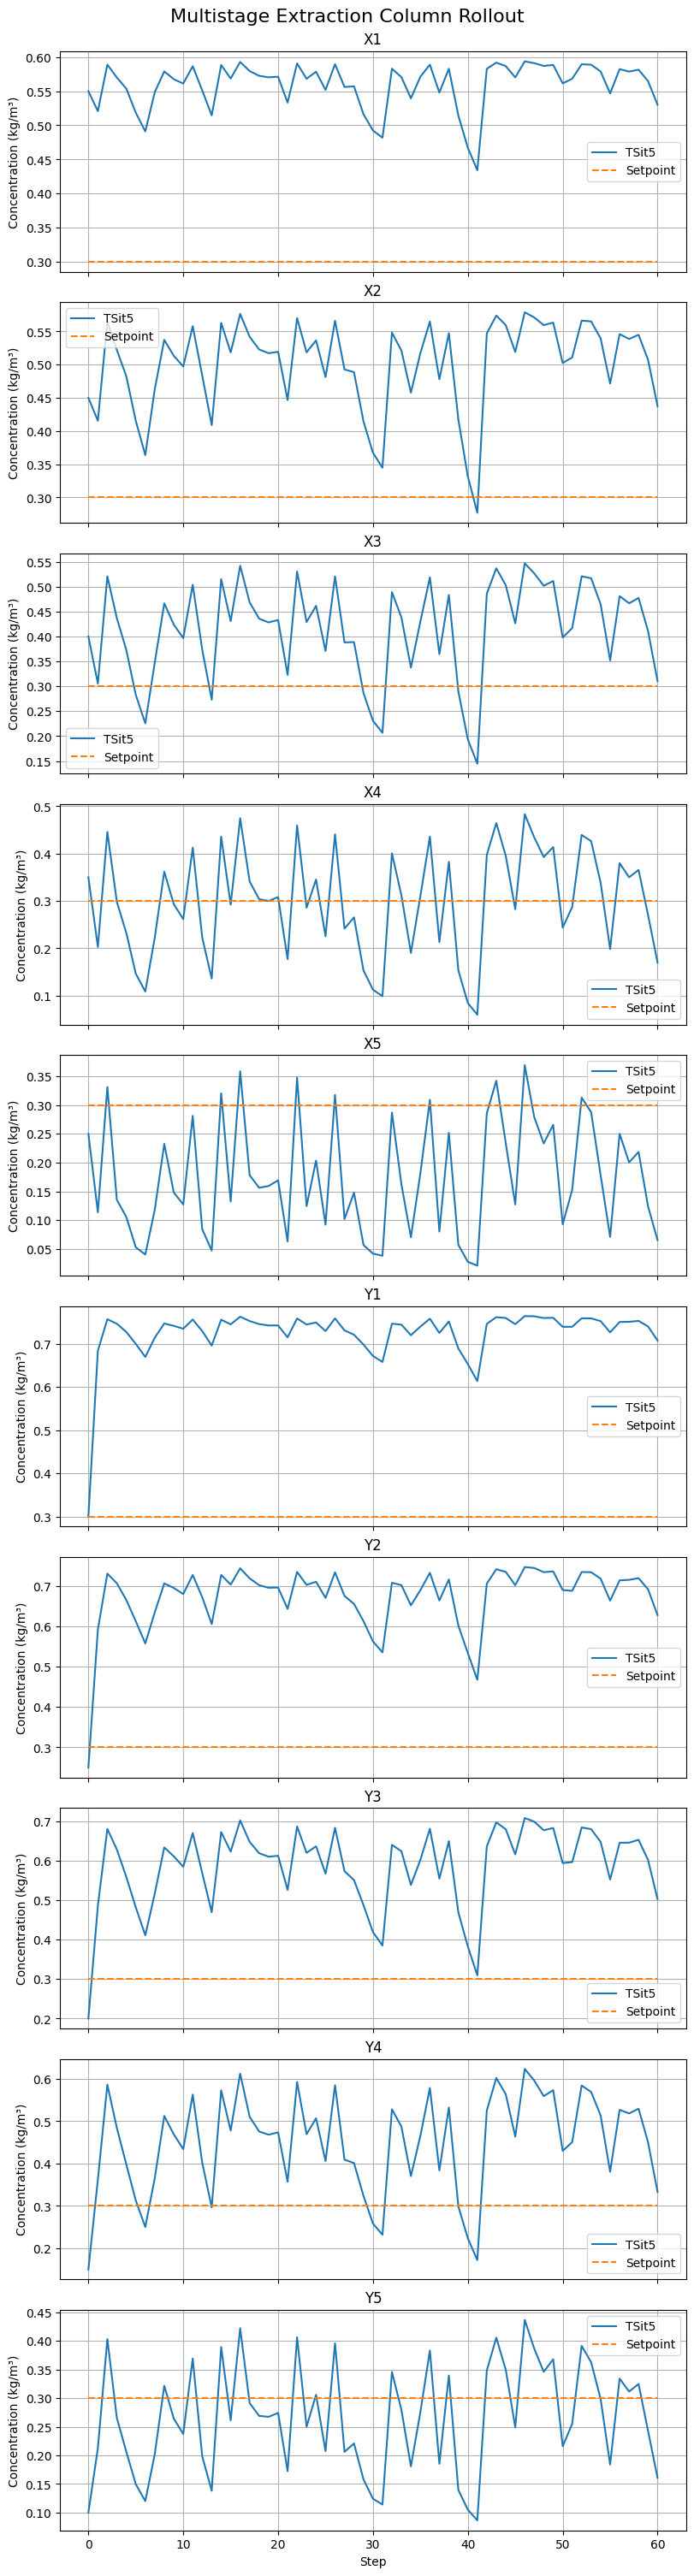

In [9]:
%matplotlib inline
plot_rollout(states)

Now let's compare with Euler integrator.

In [10]:
# Euler method for comparison
@jax.jit
def mec_next_state_euler(state, action, parameters):
    """
    MEC simulation using diffrax Euler integrator.
    """
    Vl, Vg, m, Kla, e, X0, Y6 = parameters

    L, G = action

    # Define the ODE function
    def dynamics(t, y, args):
        X1, X2, X3, X4, X5, Y1, Y2, Y3, Y4, Y5 = y

        X = jnp.array([X1, X2, X3, X4, X5])
        X_prev = jnp.array([X0, X1, X2, X3, X4])
        Y = jnp.array([Y1, Y2, Y3, Y4, Y5])
        Y_next = jnp.array([Y2, Y3, Y4, Y5, Y6])

        Xn_eq = Y ** e / m
        Qn = Kla * (X - Xn_eq) * Vl

        dX_dt = 1 / Vl * (L * (X_prev - X) - Qn)
        dY_dt = 1 / Vg * (G * (Y_next - Y) + Qn)

        return jnp.concatenate([dX_dt, dY_dt])

    solver = diffrax.Euler()

    # Initial condition
    y0 = jnp.array(state)

    term = diffrax.ODETerm(dynamics)

    sol = diffrax.diffeqsolve(
        term,
        solver,
        t0=0,
        t1=1.0,  # Each step is 1 minute
        dt0=0.1,
        y0=y0,
        args=None
    )

    return sol.ys[-1]

In [11]:
env_euler = pyRDDLGym.make('mec_ode', '0', vectorized=True, backend_kwargs={
                             'python_functions': {'next_state': mec_next_state_euler}})

In [12]:
planner_euler = JaxBackpropPlanner(rddl=env_euler.model, plan=JaxStraightLinePlan(),
                             python_functions={'next_state': mec_next_state_euler})
agent_euler = JaxOfflineController(planner_euler, print_summary=False, train_seconds=600)

states_euler, rew_euler = rollout_episode(env_euler, agent_euler)

print(f"Final reward: {rew_euler}")

[INFO] Compiler will cast pvars {"violated'", 'END-ON-VIOL', 'TRACK-SP', 'violated'} to float.
[INFO] Compiler will cast CPFs {"violated'"} to float.
[INFO] Bounds of action-fluent <action> set to (array([ 5., 10.], dtype=float32), array([ 500., 1000.], dtype=float32)).
[WARN] policy_hyperparams is not set: setting values to 1.0 for all action-fluents, which could be suboptimal.


 0 it |      -5.26528 train |      -5.26433 test |      -5.26433 best | 1 pgpe | 0 status:   3%|▎         | 00:18 , 0.05it/s

[FAIL] Training model error: Casting occurred that could result in loss of precision.


 8901 it |      -0.00000 train |      -0.00000 test |      -0.00000 best | 4484 pgpe | 5 status: 100%|██████████| 10:02 , 14.84it/s


Final reward: -1.3139310972580456e-08


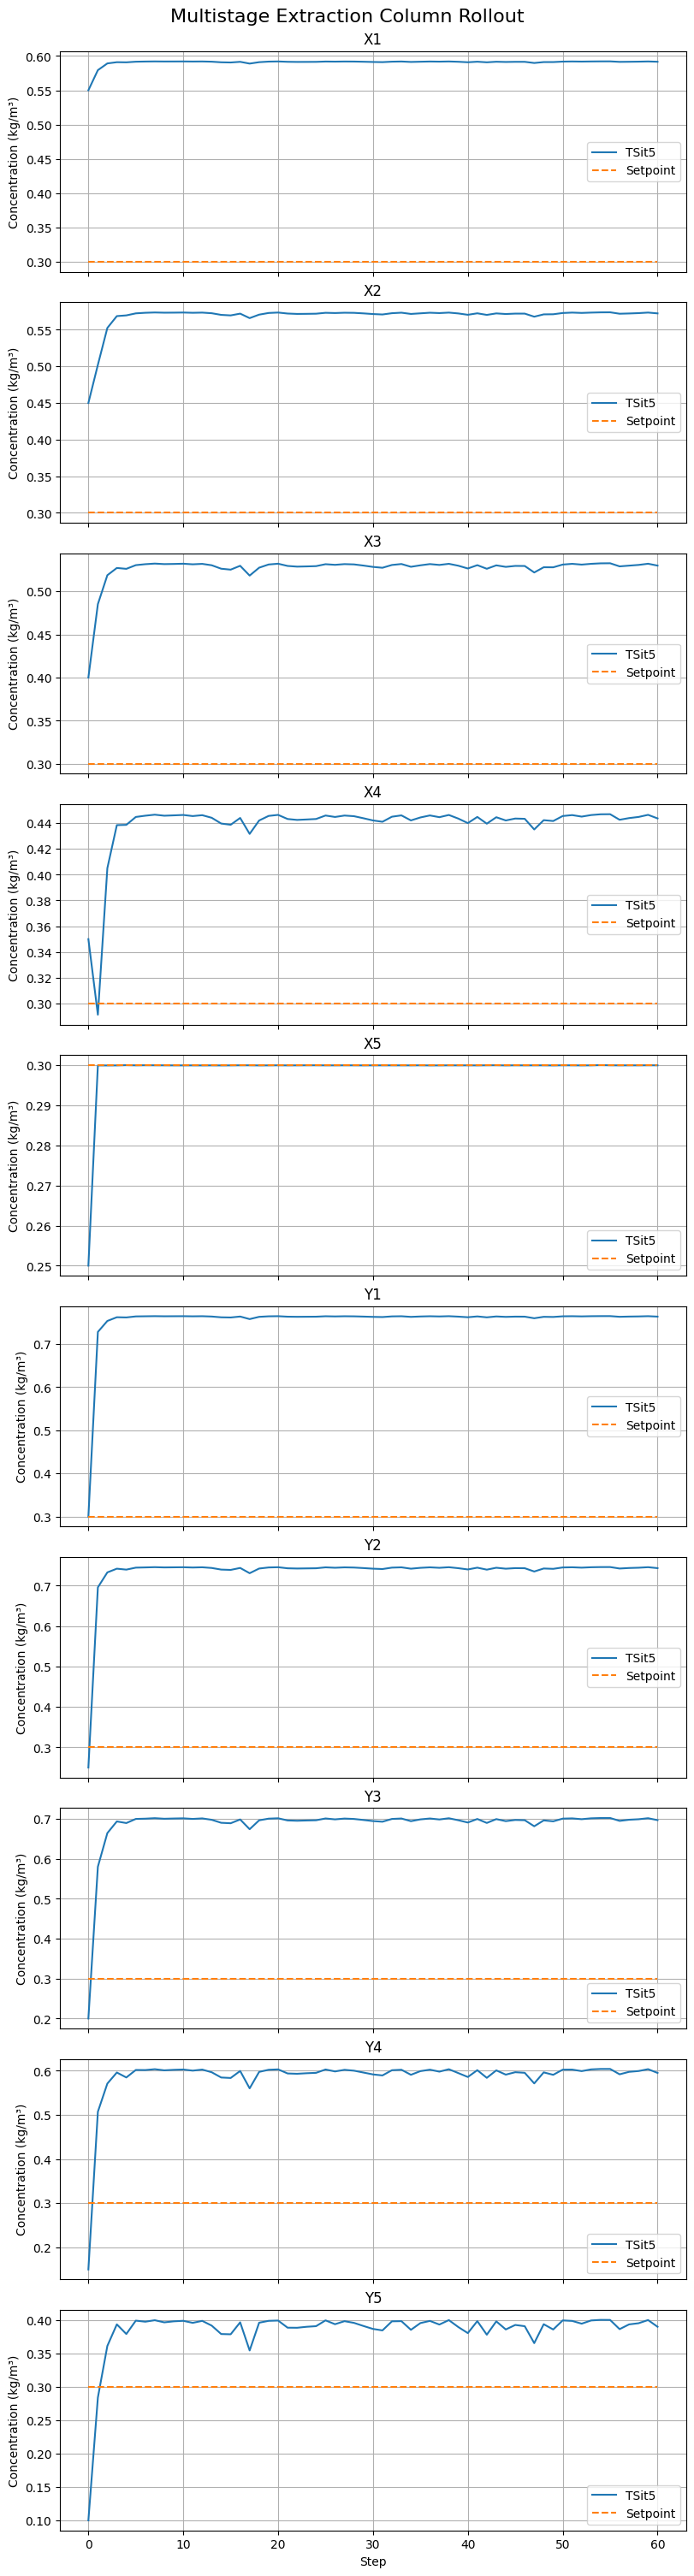

In [13]:
plot_rollout(states_euler)

We can see tradeoff between speed and ODE solution accuracy. Let's compare the two Diffrax ODE solvers with the same action sequence. For small, controlled values of actions, they perform similarly:

In [14]:
import random

actions = [[random.uniform(5, 25), random.uniform(10, 50)] for _ in range(60)]
states, rew = rollout_actions(env, actions)
states_euler, rew_euler = rollout_actions(env_euler, actions)
print(f"Cumulative reward for Euler integrator: {rew_euler}, for TSit5 integrator: {rew}")

Cumulative reward for Euler integrator: -4.756441222898721, for TSit5 integrator: -4.753820984479571


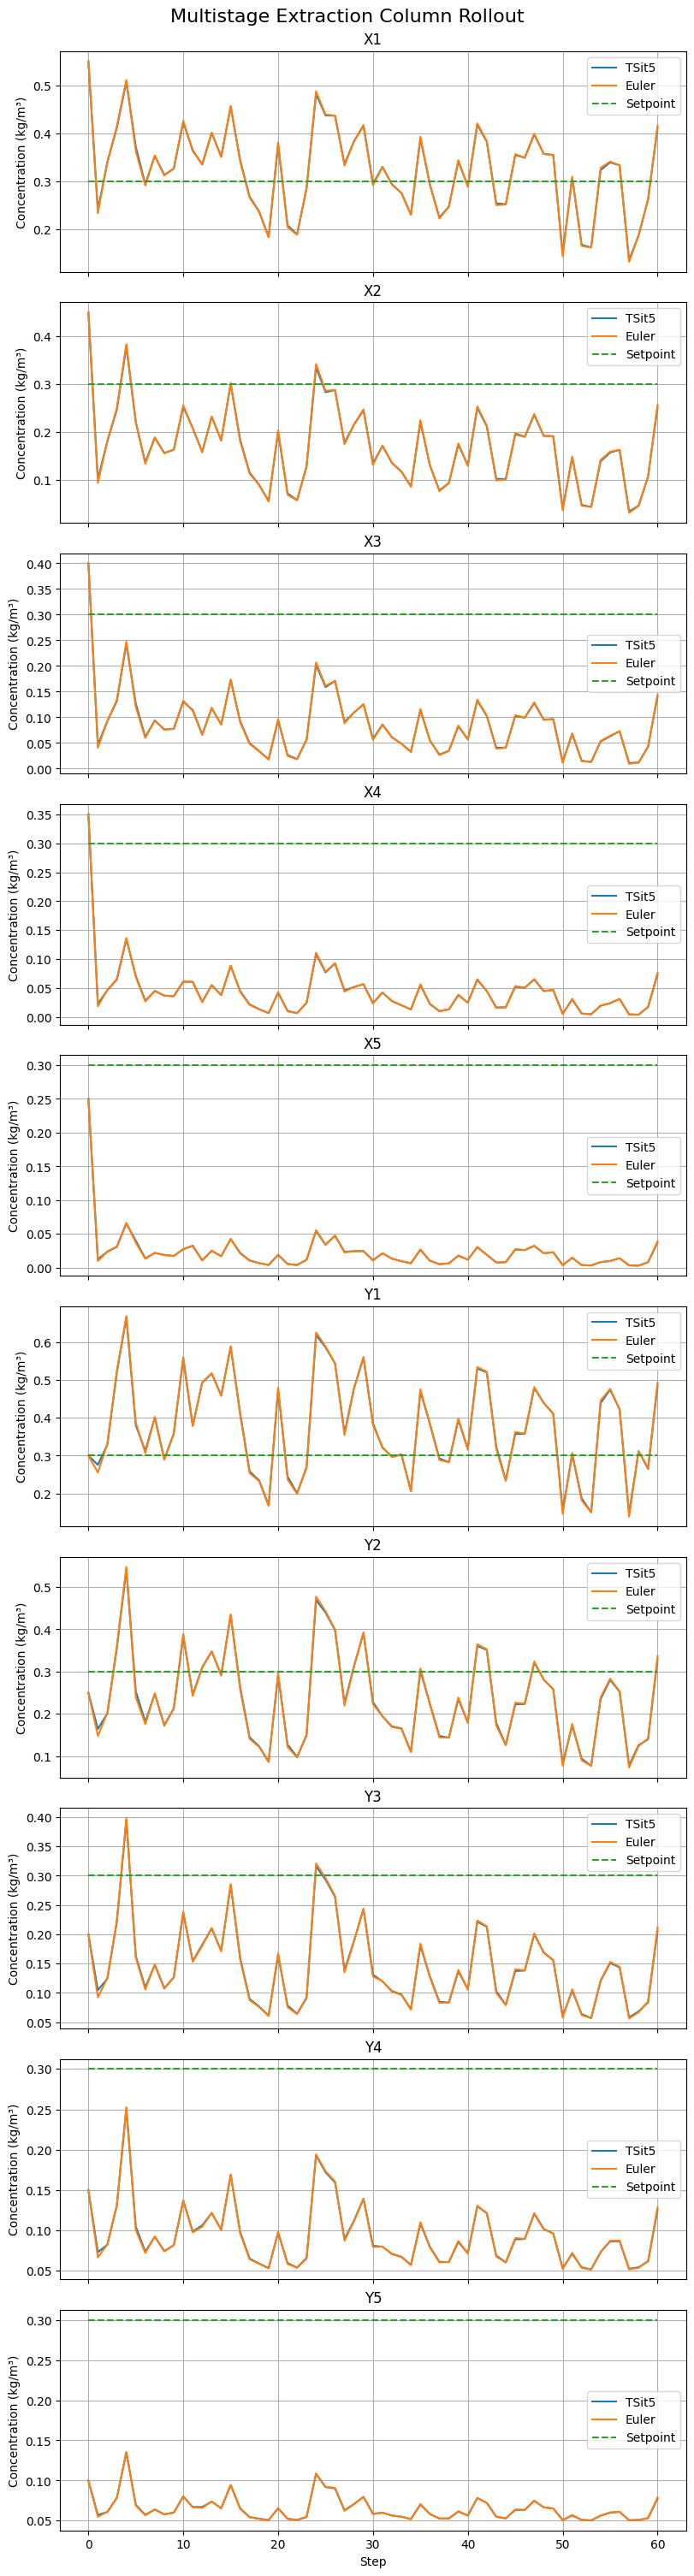

In [15]:
plot_rollout(states, states_euler)

However, when we relax the actions even a bit, Euler's method's fixed steps are too large and leads to state blowup. We could decrease the step size, but that would make the solver slower, making TSit5 a better choice.

In [16]:
actions = [[random.uniform(5, 50), random.uniform(10, 100)] for _ in range(60)]
states, rew = rollout_actions(env, actions)
states_euler, rew_euler = rollout_actions(env_euler, actions)
print(f"Cumulative reward for Euler integrator: {rew_euler}, for TSit5 integrator: {rew}")

Cumulative reward for Euler integrator: -1000.0633483078066, for TSit5 integrator: -3.590280978720947


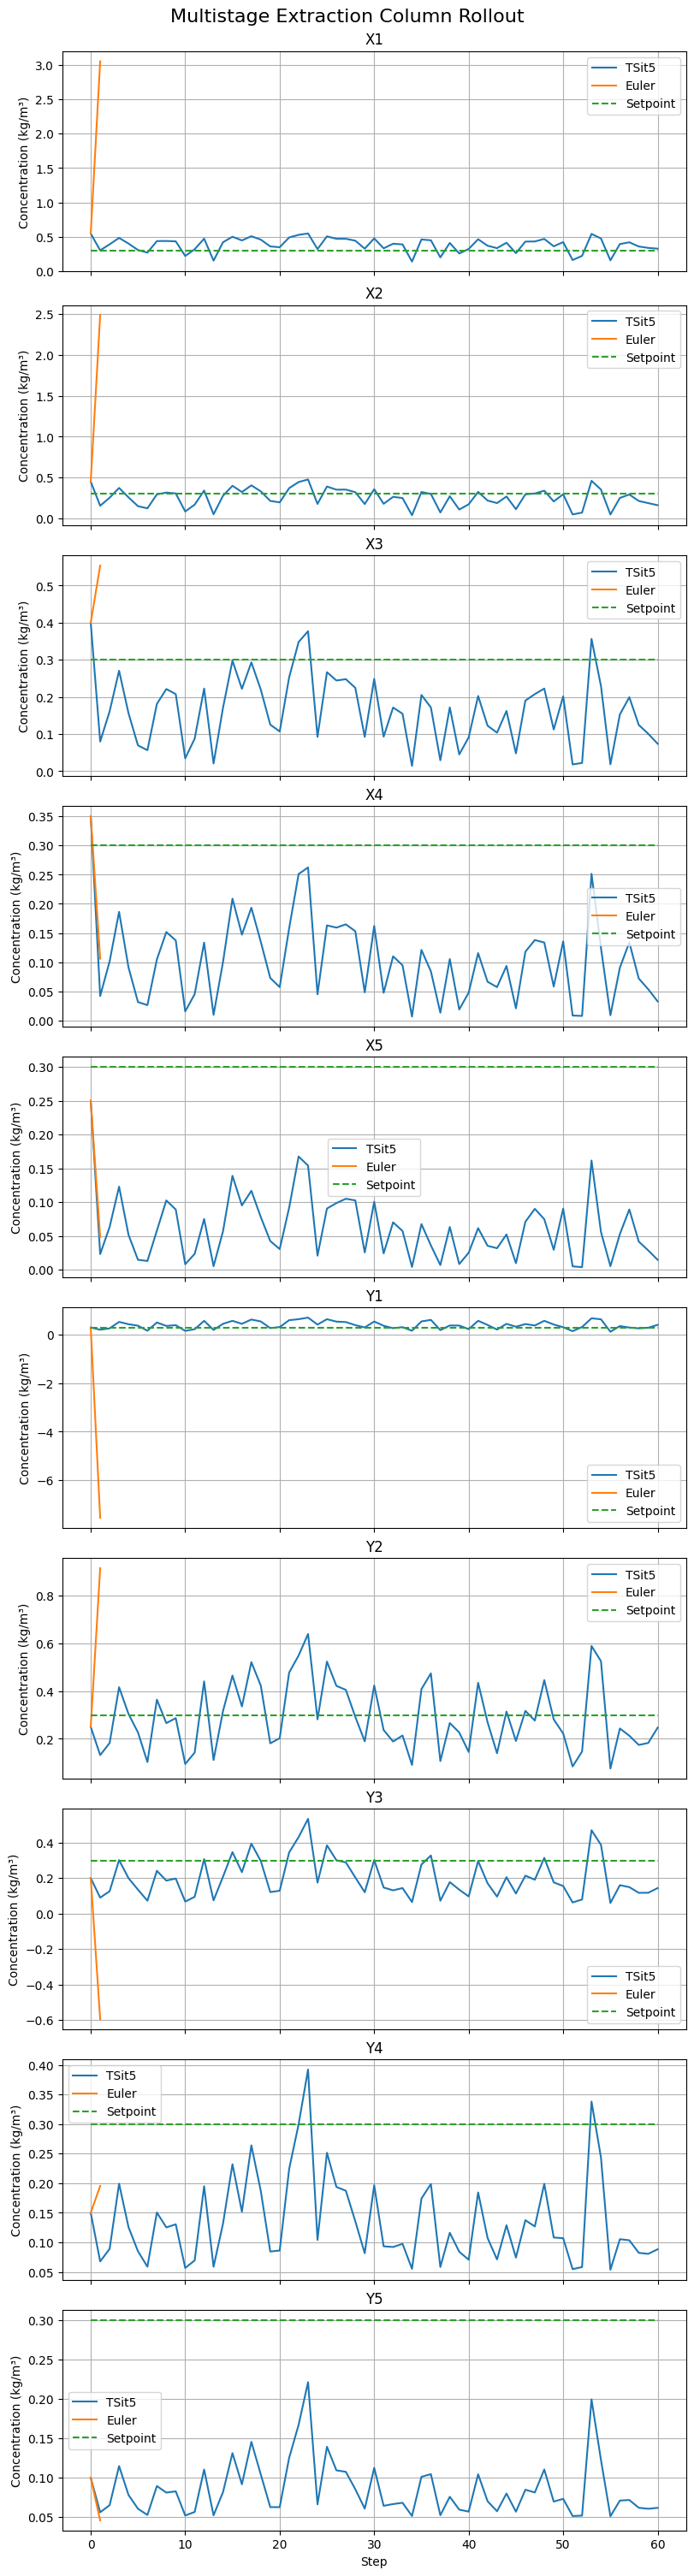

In [17]:
plot_rollout(states, states_euler)

**References**

[1] John Ingham et al. Chemical Engineering Dynamics. 3rd. Wiley, 2007

[2] Bloor, M., Torraca, J., Sandoval, I. O., et al. (2024).
*PC-Gym: Benchmark Environments For Process Control Problems*.
arXiv:2410.22093. https://arxiv.org/abs/2410.22093